# University Student Services AI Agent

Week 5 Assignment

Retrieval-Augmented Generation (RAG) with LangGraph

In [1]:
import os

from dotenv import load_dotenv

from typing import TypedDict, List

from langchain_core.documents import Document

from langchain_openai import (ChatOpenAI, OpenAIEmbeddings)

from langchain_chroma import Chroma
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_ollama import ChatOllama

from langchain_community.embeddings import HuggingFaceEmbeddings


from langgraph.graph import (StateGraph,START,END)

C:\Users\sfolaranmi\PyCharmMiscProject\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\sfolaranmi\AppData\Local\Temp\ipykernel_36420\2582981514.py:15: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.embeddings import HuggingFaceEmbeddings


In [2]:
load_dotenv()

True

In [3]:
#load knowledge documents

knowledge_docs = []

folder_path = "./knowledge_documents"

for filename in os.listdir(folder_path):

    if filename.endswith(".txt"):
        file_path = os.path.join(folder_path,filename)
        with open(file_path, "r", encoding="utf-8") as file:
            text = file.read()
            knowledge_docs.append(
                Document(
                    page_content=text,
                    metadata={
                        "source": filename
                    }
                )
            )

print(
    f"Loaded {len(knowledge_docs)} documents"
)

Loaded 8 documents


In [4]:
for doc in knowledge_docs:

    print("=" * 60)

    print(doc.metadata)

    print(doc.page_content[:300])

{'source': 'campus_services_guide.txt'}
UNIVERSITY CAMPUS SERVICES GUIDE

Version 2026

STUDENT HOUSING

The university offers both on-campus and off-campus housing assistance.

Students interested in on-campus housing must submit a Housing Application before July 1.

Housing assignments are made on a first-come, first-served basis.

Resi
{'source': 'career_services_faq.txt'}
CAREER SERVICES FREQUENTLY ASKED QUESTIONS

GENERAL SERVICES

Q: What services are offered?
A: Resume reviews, career coaching, internship support, mock interviews, networking events, employer presentations, and job search assistance.

Q: Are services free?
A: Yes, all currently enrolled students ma
{'source': 'course_registration_guide.txt'}
COURSE REGISTRATION GUIDE
Academic Year 2026–2027

OVERVIEW

The registration process allows students to enroll in courses required for degree completion. Students are responsible for ensuring registration accuracy and compliance with academic policies.

REGISTRATION PERIODS


In [5]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)

chunks = text_splitter.split_documents(
    knowledge_docs
)

print(
    f"Created {len(chunks)} chunks"
)

Created 19 chunks


In [6]:
chunks[0]

Document(metadata={'source': 'campus_services_guide.txt'}, page_content='UNIVERSITY CAMPUS SERVICES GUIDE\n\nVersion 2026\n\nSTUDENT HOUSING\n\nThe university offers both on-campus and off-campus housing assistance.\n\nStudents interested in on-campus housing must submit a Housing Application before July 1.\n\nHousing assignments are made on a first-come, first-served basis.\n\nResidence halls include:\n\n- Maple Hall\n- Oak Hall\n- Cedar Hall\n\nLIBRARY SERVICES\n\nThe University Library operates:\n\nMonday - Friday:\n8:00 AM - 10:00 PM\n\nSaturday:\n9:00 AM - 6:00 PM\n\nSunday:\n12:00 PM - 8:00 PM\n\nStudents may borrow up to 10 books simultaneously.\n\nLibrary services include:\n\n- Book lending\n- Research assistance\n- Digital databases\n- Study rooms\n- Printing services\n\nIT SUPPORT\n\nThe IT Help Desk provides technical assistance for:\n\n- Student email accounts\n- Learning Management System access\n- Wi-Fi connectivity\n- Password resets\n- Software installation\n\nSupport H

In [7]:
from langchain_huggingface import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 11734.07it/s]


In [8]:
unique_chunks = []
seen = set()

for chunk in chunks:

    content = chunk.page_content.strip()

    if content not in seen:
        seen.add(content)
        unique_chunks.append(chunk)

print(f"Original chunks: {len(chunks)}")
print(f"Unique chunks: {len(unique_chunks)}")

Original chunks: 19
Unique chunks: 19


In [9]:
vector_store = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings,
    persist_directory="./student_service_db"
)

In [10]:
retriever = vector_store.as_retriever(
    search_kwargs={ "k": 5  }
)

In [11]:
collection = vector_store._collection

print(collection.count())

38


In [12]:
print(collection.count())
print(len(chunks))

38
19


In [13]:
results = retriever.invoke(
    "What GPA is required for graduation?"
)

for doc in results:

    print(doc.metadata)

    print(doc.page_content[:500])

    print("="*50)

{'source': 'student_handbook.txt'}
UNIVERSITY STUDENT HANDBOOK

Version 2026

ACADEMIC POLICIES

Students are expected to maintain satisfactory academic progress throughout their studies.

A minimum cumulative GPA of 2.5 is required for graduation from undergraduate programs.

Students whose GPA falls below 2.0 will be placed on Academic Probation.

Students on Academic Probation for two consecutive semesters may be subject to Academic Suspension.

GRADING SYSTEM

A = 90 - 100
B = 80 - 89
C = 70 - 79
D = 60 - 69
F = Below 60

ATT
{'source': 'student_handbook.txt'}
UNIVERSITY STUDENT HANDBOOK

Version 2026

ACADEMIC POLICIES

Students are expected to maintain satisfactory academic progress throughout their studies.

A minimum cumulative GPA of 2.5 is required for graduation from undergraduate programs.

Students whose GPA falls below 2.0 will be placed on Academic Probation.

Students on Academic Probation for two consecutive semesters may be subject to Academic Suspension.

GRADING SYS

In [14]:
from langchain_ollama import ChatOllama

llm = ChatOllama(
    model="llama3",
    temperature=0
)


In [15]:
print(llm)

output_version=None model='llama3' temperature=0.0


In [16]:
class AgentState(TypedDict, total=False):
    question: str
    route: str
    documents: List[Document]
    answer: str
    reviewed_answer: str
    conversation_history: List[str]

In [17]:
def update_memory(state):

    history = state.get(
        "conversation_history",
        []
    )

    history.append(
        f"User: {state['question']}"
    )

    history.append(
        f"Assistant: {state['reviewed_answer']}"
    )

    return {
        "conversation_history": history
    }

In [18]:
def route_question(state):

    question = state["question"]

    prompt = f"""
    Classify the question.

    Return only:

    knowledge

    or

    general

    Question:
    {question}
    """

    response = llm.invoke(prompt)

    print("RAW RESPONSE:", response.content)

    route = response.content.strip().lower()

    print("ROUTE:", route)

    return {
        "route": route
    }

In [19]:
def retrieve_documents(state):

    docs = retriever.invoke(state["question"])

    unique_docs = []
    seen = set()

    for doc in docs:

        content = doc.page_content.strip()

        if content not in seen:
            seen.add(content)
            unique_docs.append(doc)

    return {
        "documents": unique_docs
    }

In [20]:
def generate_rag_answer(state):

    context = "\n\n".join(doc.page_content
        for doc in state["documents"]
    )

    history = "\n".join(
        state.get(
            "conversation_history",
            []
        )
    )

    prompt = f"""You are a university assistant.
    Use ONLY the information contained in the context.
    If the answer cannot be found,
    respond:
    "I could not find that information
    in the university documents."

    Conversation History:
    {history}

    Context:
    {context}

    Question:
    {state['question']}
    """

    answer = (
        llm.invoke(prompt).content
    )

    return {
        "answer": answer
    }

In [21]:
def generate_general_answer(state):

    history = "\n".join(
        state.get(
            "conversation_history",
            []
        )
    )

    prompt = f"""
    Conversation History:
    {history}

    User Question:
    {state['question']}
    """

    response = llm.invoke(prompt)

    return {
        "answer": response.content
    }

In [22]:
def review_answer(state):

    answer = state["answer"]

    prompt = f"""
    You are an editor.

    Review the answer below.

    If improvements are needed, rewrite the answer.

    If no improvements are needed, return the answer exactly as it is.

    IMPORTANT:
    Return ONLY the final revised answer.
    Do NOT explain your review.
    Do NOT give feedback.
    Do NOT mention clarity, grammar, or completeness.

    Answer:
    {answer}
    """

    response = llm.invoke(prompt)

    return {
        "reviewed_answer": response.content.strip()
    }

In [23]:
def determine_path(state):

    return state["route"]

In [24]:
graph = StateGraph(AgentState)

graph.add_node("memory", update_memory)
graph.add_node("router", route_question)
graph.add_node("retrieve",retrieve_documents)
graph.add_node("rag_answer", generate_rag_answer)
graph.add_node("general_answer", generate_general_answer)
graph.add_node("review", review_answer)

In [25]:
graph.add_edge( START,"router")
graph.add_conditional_edges("router", determine_path,
    {
        "knowledge": "retrieve",
        "general": "general_answer"
    }
)
graph.add_edge("retrieve", "rag_answer")
graph.add_edge("rag_answer", "review")
graph.add_edge("general_answer", "review")
graph.add_edge("review", "memory")
graph.add_edge("memory", END)

In [26]:
#workflow = graph.compile()

from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

workflow = graph.compile(
    checkpointer=memory
)

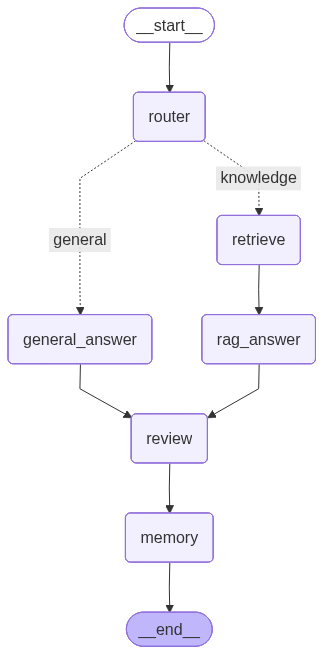

In [28]:
from IPython.display import Image, display

display(Image(workflow.get_graph().draw_mermaid_png(max_retries=5, retry_delay=2.0)))

# Testing the University Student Services AI Agent

In [29]:
config = {
    "configurable": {
        "thread_id": "student_demo"
    }
}

In [30]:
result = workflow.invoke(
    {
        "question":
        "What GPA is required for graduation?"
    },
    config=config
)

print(result["reviewed_answer"])

RAW RESPONSE: knowledge
ROUTE: knowledge
According to the University Student Handbook, Version 2026, students are expected to maintain a minimum cumulative GPA of 2.5 for graduation from undergraduate programs.


In [31]:
result = workflow.invoke(
    {
        "question":
        "What happens if it falls below that?"
    },
    config=config
)

print(result["reviewed_answer"])

RAW RESPONSE: general
ROUTE: general
According to the University's Academic Progress Policy, if your cumulative GPA falls below 2.5, you will be placed on academic probation. During this time, you'll need to work with your academic advisor and/or a counselor to develop a plan to get your GPA back up to the required level.

If your GPA remains below 2.5 at the end of the probationary period, you may face further consequences, such as being suspended from the university or having your financial aid eligibility revoked. It's essential to stay on top of your grades and seek help if you're struggling to avoid these outcomes.

It's also worth noting that some programs or majors may have more stringent GPA requirements than the overall university minimum. If you're concerned about your GPA or have questions about academic probation, I recommend speaking with your academic advisor or a counselor for personalized guidance.


In [32]:
result = workflow.invoke(
    {
        "question":
        "How long can they remain on probation?"
    },
    config=config
)

print(result["reviewed_answer"])

RAW RESPONSE: general
ROUTE: general
According to the University's Academic Progress Policy, students placed on academic probation can remain on probation for up to two semesters. During this time, they must work with their academic advisor and/or a counselor to develop a plan to improve their GPA to the required level.

If a student's cumulative GPA remains below 2.5 at the end of the second semester on probation, they may face further consequences, including suspension from the university or revocation of financial aid eligibility.

It is crucial for students on academic probation to monitor their grades and seek help if needed to avoid these outcomes.


In [33]:
snapshot = workflow.get_state(config)

print(snapshot.values)

{'question': 'How long can they remain on probation?', 'route': 'general', 'documents': [Document(id='1ee937ac-8d4a-4577-9071-2e9c9a719aa3', metadata={'source': 'student_handbook.txt'}, page_content='UNIVERSITY STUDENT HANDBOOK\n\nVersion 2026\n\nACADEMIC POLICIES\n\nStudents are expected to maintain satisfactory academic progress throughout their studies.\n\nA minimum cumulative GPA of 2.5 is required for graduation from undergraduate programs.\n\nStudents whose GPA falls below 2.0 will be placed on Academic Probation.\n\nStudents on Academic Probation for two consecutive semesters may be subject to Academic Suspension.\n\nGRADING SYSTEM\n\nA = 90 - 100\nB = 80 - 89\nC = 70 - 79\nD = 60 - 69\nF = Below 60\n\nATTENDANCE POLICY\n\nStudents must attend at least 75% of all scheduled classes.\n\nStudents who miss more than 25% of classes without approved justification may be barred from taking final examinations.\n\nAbsences due to illness, family emergencies, or university-approved activi